# Module 3.17 — Turbulence Basics

**Why turbulence matters:** It appears in virtually every engineering flow — jet engines, wind turbines, blood flow, weather. And it is the last great unsolved problem of classical physics.

**What you will learn:**
- The energy cascade and Kolmogorov microscales
- Reynolds decomposition: $u = \bar{u} + u'$
- How RANS equations are derived from NS
- The closure problem and why models are needed
- Boussinesq hypothesis and eddy viscosity
- The Prandtl mixing-length model (implemented in Python)
- Overview of $k$–$\varepsilon$ and $k$–$\omega$ SST models

In [9]:
import numpy as np
import matplotlib.pyplot as plt

## 1. The Energy Cascade

Turbulence is not random noise — it has a precise multi-scale structure. Energy enters at large scales (the domain geometry), cascades through intermediate scales, and is dissipated as heat at the smallest scales.

**Richardson (1922):**
> *"Big whirls have little whirls that feed on their velocity,*
> *and little whirls have lesser whirls, and so on to viscosity."*

### The three scale ranges

| Range | Size | Physics |
|---|---|---|
| Energy-containing range | $\sim L$ (integral scale) | Large eddies fed by mean shear |
| Inertial subrange | $\eta \ll \ell \ll L$ | Energy cascades, no production or dissipation |
| Dissipation range | $\sim \eta$ (Kolmogorov scale) | Viscosity converts KE → heat |

### Kolmogorov microscales

The smallest eddy size $\eta$ where Re = 1 (inertia = viscosity):

$$\eta = \left(\frac{\nu^3}{\varepsilon}\right)^{1/4}$$

$$u_\eta = (\nu\,\varepsilon)^{1/4} \qquad \tau_\eta = \left(\frac{\nu}{\varepsilon}\right)^{1/2}$$

where $\varepsilon$ is the turbulent kinetic energy dissipation rate (W/kg) and $\nu$ is kinematic viscosity.

Relating to the integral scale $L$ and velocity $U$:

$$\frac{\eta}{L} \sim Re^{-3/4} \qquad \frac{u_\eta}{U} \sim Re^{-1/4}$$

**DNS cost:** you need $N \sim Re^{3/4}$ grid points per dimension:

$$\text{Total grid points (3D)} \sim Re^{9/4}, \quad \text{Time steps} \sim Re^{3/4} \implies \text{Cost} \sim Re^{3}$$

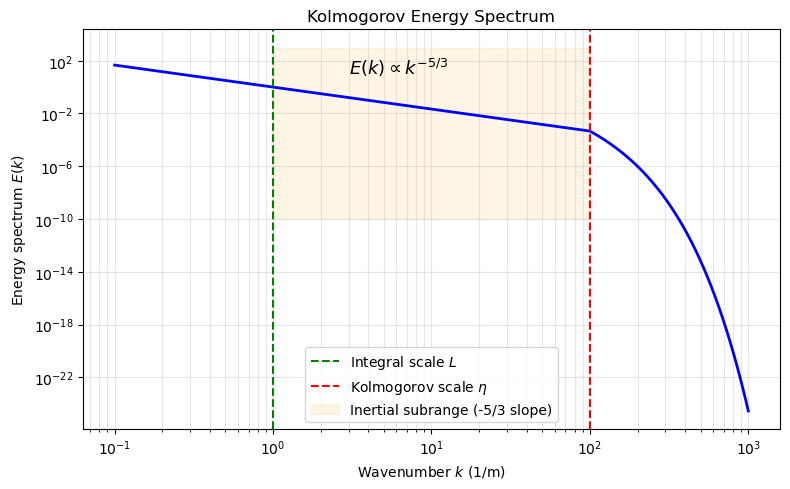

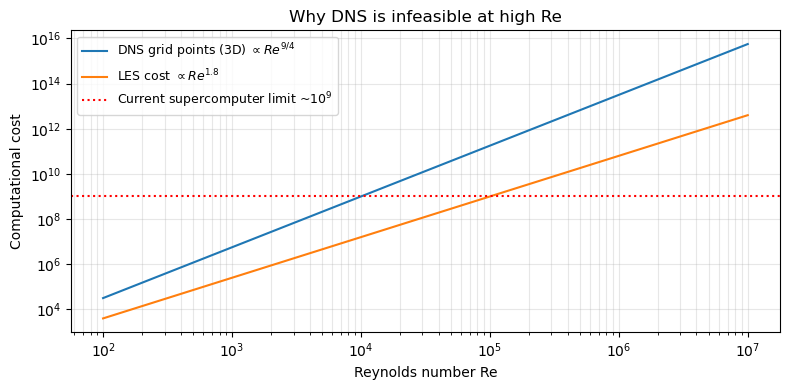

In [10]:
# Kolmogorov -5/3 energy spectrum (Kolmogorov 1941)
k = np.logspace(-1, 3, 500)   # wavenumber (1/m)
E = k**(-5/3)
E[k > 100] *= np.exp(-(k[k > 100] - 100) / 20)  # dissipation roll-off

plt.figure(figsize=(8, 5))
plt.loglog(k, E, 'b-', linewidth=2)
plt.axvline(1,   color='green',  linestyle='--', label='Integral scale $L$')
plt.axvline(100, color='red',    linestyle='--', label='Kolmogorov scale $\\eta$')
plt.fill_betweenx([1e-10, 1e3], 1, 100, alpha=0.1, color='orange', label='Inertial subrange (-5/3 slope)')
plt.text(3, 1e1, '$E(k) \\propto k^{-5/3}$', fontsize=13)
plt.xlabel('Wavenumber $k$ (1/m)'); plt.ylabel('Energy spectrum $E(k)$')
plt.title('Kolmogorov Energy Spectrum')
plt.legend(); plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# DNS cost scaling
Re_arr = np.logspace(2, 7, 100)
plt.figure(figsize=(8, 4))
plt.loglog(Re_arr, Re_arr**(9/4), label='DNS grid points (3D) $\\propto Re^{9/4}$')
plt.loglog(Re_arr, Re_arr**(1.8), label='LES cost $\\propto Re^{1.8}$')
plt.axhline(1e9, color='red', linestyle=':', label='Current supercomputer limit ~$10^9$')
plt.xlabel('Reynolds number Re'); plt.ylabel('Computational cost')
plt.title('Why DNS is infeasible at high Re')
plt.legend(fontsize=9); plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Reynolds Decomposition

Any turbulent flow variable $\phi$ is decomposed into a **mean** and a **fluctuation**:

$$\phi(\mathbf{x}, t) = \underbrace{\bar{\phi}(\mathbf{x})}_{\text{time mean}} + \underbrace{\phi'(\mathbf{x}, t)}_{\text{fluctuation}}$$

where the time average is:

$$\bar{\phi} = \lim_{T\to\infty} \frac{1}{T}\int_0^T \phi\, dt$$

**Key properties** (used to derive RANS):

| Rule | Expression |
|---|---|
| Mean of fluctuation | $\overline{\phi'} = 0$ |
| Mean of mean | $\bar{\bar{\phi}} = \bar{\phi}$ |
| Linearity | $\overline{\phi + \psi} = \bar{\phi} + \bar{\psi}$ |
| Product (non-trivial!) | $\overline{\phi\,\psi} = \bar{\phi}\,\bar{\psi} + \overline{\phi'\psi'}$ |

The **product rule** is the critical one — it creates a new non-zero term $\overline{\phi'\psi'}$ even though $\overline{\phi'} = 0$ and $\overline{\psi'} = 0$ individually.

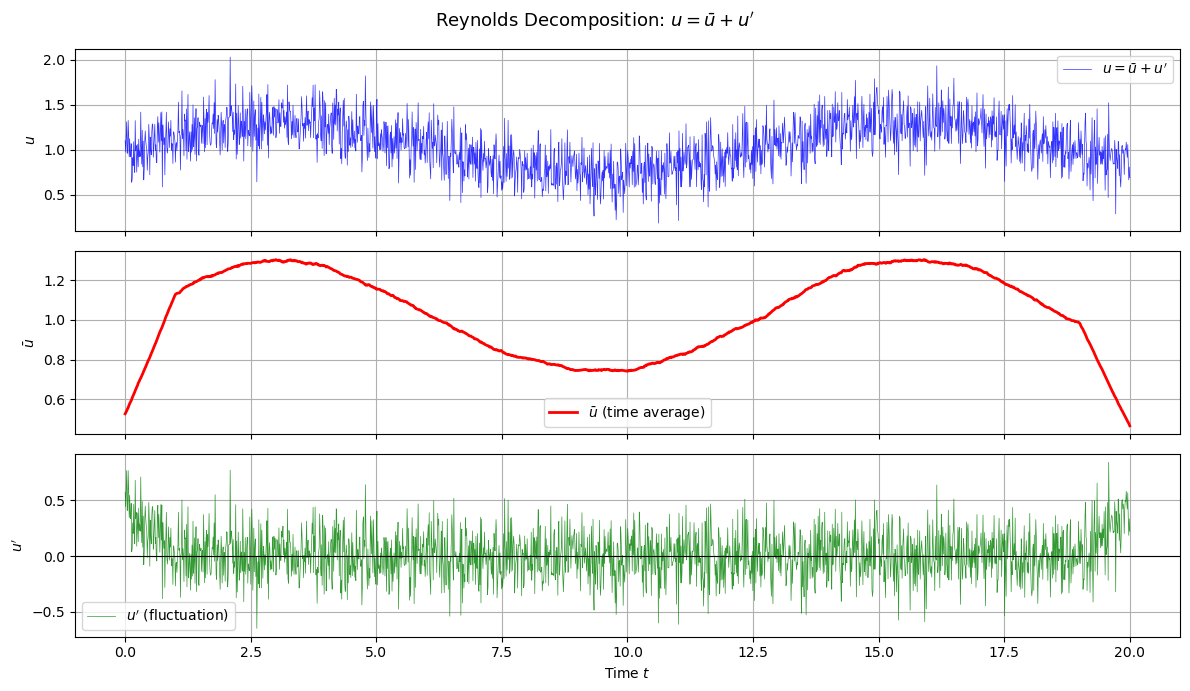

Mean of fluctuation  u_bar(u') = 0.024117  (should be ~0)
RMS of fluctuation   u'_rms    = 0.2114
Turbulence intensity             = 20.3%


In [11]:
# Demonstrate Reynolds decomposition on a synthetic turbulent signal
np.random.seed(42)
t = np.linspace(0, 20, 2000)
u_mean = 1.0 + 0.3 * np.sin(0.5 * t)           # slow mean variation
u_prime = 0.2 * np.random.randn(len(t))         # turbulent fluctuation
u_total = u_mean + u_prime

# Time-averaged mean (window average)
window = 200
u_bar = np.convolve(u_total, np.ones(window)/window, mode='same')

fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(t, u_total, 'b-', lw=0.5, alpha=0.8, label='$u = \\bar{u} + u\'$')
axes[0].set_ylabel('$u$'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(t, u_bar, 'r-', lw=2, label='$\\bar{u}$ (time average)')
axes[1].set_ylabel('$\\bar{u}$'); axes[1].legend(); axes[1].grid(True)
axes[2].plot(t, u_total - u_bar, 'g-', lw=0.5, alpha=0.8, label="$u'$ (fluctuation)")
axes[2].axhline(0, color='k', lw=0.8)
axes[2].set_ylabel("$u'$"); axes[2].set_xlabel('Time $t$')
axes[2].legend(); axes[2].grid(True)
plt.suptitle('Reynolds Decomposition: $u = \\bar{u} + u\'$', fontsize=13)
plt.tight_layout()
plt.show()

u_fluct = u_total - u_bar
print(f"Mean of fluctuation  u_bar(u') = {np.mean(u_fluct):.6f}  (should be ~0)")
print(f"RMS of fluctuation   u'_rms    = {np.std(u_fluct):.4f}")
print(f"Turbulence intensity             = {np.std(u_fluct)/np.mean(u_bar)*100:.1f}%")

## 3. Reynolds-Averaged Navier–Stokes (RANS)

Substitute $u_i = \bar{u}_i + u_i'$ into the incompressible NS equations and time-average.

**Step 1 — Continuity** (simple — linear in $u$):

$$\frac{\partial \bar{u}_i}{\partial x_i} = 0$$

**Step 2 — Momentum** (the product rule creates a new term):

Starting from:
$$\frac{\partial u_i}{\partial t} + \frac{\partial (u_i u_j)}{\partial x_j} = -\frac{1}{\rho}\frac{\partial p}{\partial x_i} + \nu\frac{\partial^2 u_i}{\partial x_j \partial x_j}$$

After substituting $u_i = \bar{u}_i + u_i'$ and time-averaging:

$$\boxed{\frac{\partial \bar{u}_i}{\partial t} + \bar{u}_j\frac{\partial \bar{u}_i}{\partial x_j} = -\frac{1}{\rho}\frac{\partial \bar{p}}{\partial x_i} + \nu\frac{\partial^2 \bar{u}_i}{\partial x_j^2} - \frac{\partial}{\partial x_j}\underbrace{\overline{u_i' u_j'}}_{\text{Reynolds stress}}}$$

### The Reynolds Stress Tensor

$$\tau_{ij}^{\text{Re}} = -\rho\,\overline{u_i' u_j'} = -\rho\begin{pmatrix} \overline{u'u'} & \overline{u'v'} & \overline{u'w'} \\ \overline{v'u'} & \overline{v'v'} & \overline{v'w'} \\ \overline{w'u'} & \overline{w'v'} & \overline{w'w'} \end{pmatrix}$$

This is **symmetric** (6 independent components) and represents the momentum transport by turbulent fluctuations — the same role that viscous stress plays in laminar flow, but much larger.

### The Closure Problem

The RANS equations have **more unknowns than equations**: we now need to know $\overline{u_i' u_j'}$ (6 new unknowns per point) but we only have 4 equations (3 momentum + 1 continuity). We cannot close the system without a **turbulence model**.

## 4. Boussinesq Hypothesis — Eddy Viscosity

By analogy with the viscous stress $\tau_{ij} = 2\mu S_{ij}$ (where $S_{ij}$ is the strain rate tensor), Boussinesq (1877) proposed:

$$-\rho\,\overline{u_i' u_j'} = 2\,\mu_t\,\bar{S}_{ij} - \frac{2}{3}\rho k\,\delta_{ij}$$

where:
- $\mu_t = \rho\,\nu_t$ is the **eddy viscosity** (turbulent viscosity) — NOT a fluid property, a flow property
- $\bar{S}_{ij} = \frac{1}{2}\left(\frac{\partial \bar{u}_i}{\partial x_j} + \frac{\partial \bar{u}_j}{\partial x_i}\right)$ is the mean strain rate tensor
- $k = \frac{1}{2}\overline{u_i' u_i'}$ is the **turbulent kinetic energy** (TKE)
- $\delta_{ij}$ is the Kronecker delta (absorbed into pressure in practice)

This reduces the closure problem to finding **one scalar field** $\nu_t(\mathbf{x}, t)$ instead of 6 tensor components.

**Key insight:** in a turbulent shear flow, $\nu_t \gg \nu$ — the effective viscosity is dominated by turbulence:

$$\nu_{\text{eff}} = \nu + \nu_t \approx \nu_t \quad (\nu_t / \nu \sim 10^2 \text{ to } 10^5)$$

## 5. Prandtl Mixing-Length Model

The simplest eddy viscosity model. For a 2D shear flow in $x$ with gradient in $y$:

$$\nu_t = \ell_m^2 \left|\frac{d\bar{u}}{dy}\right|$$

where $\ell_m$ is the **mixing length** — the distance a fluid parcel travels before losing its identity.

Near a wall: $\ell_m = \kappa\,y$ where $\kappa \approx 0.41$ is the **von Kármán constant**.

This gives the famous **log-law of the wall**:

$$\bar{u}^+ = \frac{1}{\kappa}\ln(y^+) + B$$

where $u^+ = \bar{u}/u_\tau$, $y^+ = y u_\tau/\nu$, $u_\tau = \sqrt{\tau_w/\rho}$ is the **friction velocity**, and $B \approx 5.2$.

**Wall regions:**

| Layer | Range | Profile |
|---|---|---|
| Viscous sublayer | $y^+ < 5$ | $u^+ = y^+$ (linear) |
| Buffer layer | $5 < y^+ < 30$ | Transition |
| Log-law region | $y^+ > 30$ | $u^+ = \frac{1}{\kappa}\ln y^+ + B$ |

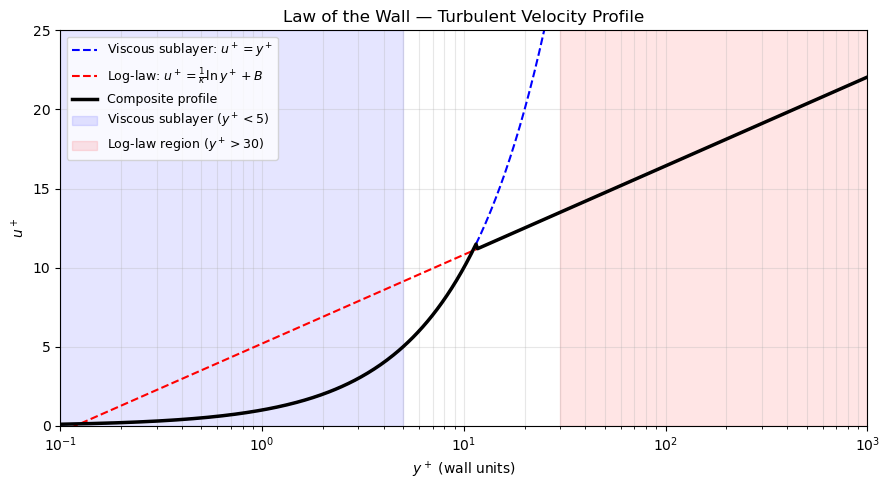

Friction velocity    u_tau = 0.0500 m/s
Viscous length scale nu/u_tau = 0.2000 mm


In [12]:
# Turbulent channel flow — log-law velocity profile
kappa = 0.41   # von Karman constant
B     = 5.2    # log-law intercept
nu    = 1e-5   # kinematic viscosity (m^2/s)
u_tau = 0.05   # friction velocity (m/s)

y_plus = np.logspace(-1, 3, 500)   # y+ range

# Viscous sublayer: u+ = y+
u_viscous = y_plus

# Log-law region: u+ = (1/kappa)*ln(y+) + B
u_log = (1/kappa) * np.log(y_plus) + B

# Composite: take min(viscous, log) where log takes over
u_composite = np.where(y_plus < 11.6, u_viscous, u_log)

plt.figure(figsize=(9, 5))
plt.semilogx(y_plus, u_viscous,   'b--', lw=1.5, label='Viscous sublayer: $u^+ = y^+$')
plt.semilogx(y_plus, u_log,       'r--', lw=1.5, label=r'Log-law: $u^+ = \frac{1}{\kappa}\ln y^+ + B$')
plt.semilogx(y_plus, u_composite, 'k-',  lw=2.5, label='Composite profile')
plt.axvspan(0.1, 5,   alpha=0.1, color='blue',   label='Viscous sublayer ($y^+<5$)')
plt.axvspan(30, 1000, alpha=0.1, color='red',    label='Log-law region ($y^+>30$)')
plt.xlabel('$y^+$ (wall units)'); plt.ylabel('$u^+$')
plt.title('Law of the Wall — Turbulent Velocity Profile')
plt.legend(fontsize=9); plt.grid(True, which='both', alpha=0.3)
plt.xlim([0.1, 1000]); plt.ylim([0, 25])
plt.tight_layout()
plt.show()

print(f'Friction velocity    u_tau = {u_tau:.4f} m/s')
print(f'Viscous length scale nu/u_tau = {nu/u_tau*1000:.4f} mm')

## 6. Turbulence Models — Overview

| Model | Transport eqs | $\nu_t$ from | Strengths | Weaknesses |
|---|---|---|---|---|
| **Mixing length** | 0 | Algebraic: $\ell_m^2 |d\bar{u}/dy|$ | Simple, cheap | Only for simple shear flows |
| **Spalart-Allmaras** | 1 ($\tilde{\nu}$) | $\tilde{\nu}$ transport | Good for aerodynamics | Poor for separated flows |
| **$k$–$\varepsilon$** | 2 ($k$, $\varepsilon$) | $\nu_t = C_\mu k^2/\varepsilon$ | Robust, widely used | Poor near walls |
| **$k$–$\omega$ SST** | 2 ($k$, $\omega$) | Blends $k$–$\varepsilon$/$k$–$\omega$ | Best for wall-bounded flows | More expensive |
| **RSM** | 7 ($\tau_{ij}$ transport) | Direct | Most physical | Very expensive, unstable |
| **LES** | Filtered NS | SGS model | Captures large eddies | $Re^{1.8}$ cost |
| **DNS** | Full NS | None | Exact | $Re^{3}$ cost — infeasible >10,000 |

**Industry standard:** $k$–$\omega$ SST (OpenFOAM default, Fluent default for wall-bounded flows)

### $k$–$\varepsilon$ Model Equations

Two additional transport equations for TKE $k$ and dissipation rate $\varepsilon$:

$$\frac{\partial k}{\partial t} + \bar{u}_j\frac{\partial k}{\partial x_j} = \underbrace{P_k}_{\text{production}} - \underbrace{\varepsilon}_{\text{dissipation}} + \frac{\partial}{\partial x_j}\left[\left(\nu + \frac{\nu_t}{\sigma_k}\right)\frac{\partial k}{\partial x_j}\right]$$

$$\frac{\partial \varepsilon}{\partial t} + \bar{u}_j\frac{\partial \varepsilon}{\partial x_j} = C_{\varepsilon 1}\frac{\varepsilon}{k}P_k - C_{\varepsilon 2}\frac{\varepsilon^2}{k} + \frac{\partial}{\partial x_j}\left[\left(\nu + \frac{\nu_t}{\sigma_\varepsilon}\right)\frac{\partial \varepsilon}{\partial x_j}\right]$$

where $\nu_t = C_\mu k^2/\varepsilon$, and $C_\mu=0.09$, $C_{\varepsilon1}=1.44$, $C_{\varepsilon2}=1.92$, $\sigma_k=1.0$, $\sigma_\varepsilon=1.3$ are empirical constants.

## Summary

| Concept | Key formula |
|---|---|
| Kolmogorov microscale | $\eta = (\nu^3/\varepsilon)^{1/4} \sim L\,Re^{-3/4}$ |
| DNS cost | $\sim Re^{3}$ (infeasible for Re > 10,000 in 3D) |
| Reynolds decomposition | $u = \bar{u} + u'$, $\;\overline{u'} = 0$ |
| RANS momentum | Extra term $-\partial(\rho\overline{u_i'u_j'})/\partial x_j$ (Reynolds stress) |
| Boussinesq hypothesis | $-\rho\overline{u_i'u_j'} = 2\mu_t \bar{S}_{ij} - \frac{2}{3}\rho k\delta_{ij}$ |
| Mixing-length model | $\nu_t = \ell_m^2|d\bar{u}/dy|$, $\;\ell_m = \kappa y$ near wall |
| Log-law of the wall | $u^+ = \frac{1}{\kappa}\ln y^+ + B$ for $y^+ > 30$ |
| $k$–$\varepsilon$ eddy viscosity | $\nu_t = C_\mu k^2/\varepsilon$ |

**Next:** Module 3.18 — Turbulence Models in detail ($k$–$\varepsilon$, $k$–$\omega$ SST, wall functions)